***Introduction***

**Project Title:**
Loan Approval Prediction using Machine Learning

**Project Objective:**
Banks receive thousands of loan applications every day. Approving a loan manually takes time and may introduce human bias.

The objective of this project is to build a Machine Learning model that predicts whether a customer's loan application will be approved based on demographic and financial information.

This project demonstrates the complete Machine Learning lifecycle from data preprocessing to model evaluation.

**Problem Statement**

Develop a Machine Learning model that predicts whether a loan application will be

Approved (Y)

Rejected (N)

using customer information such as

Income

Education

Marital Status

Loan Amount

Credit History

Property Area etc...




***ML Lifecycle***


Business Problem

        ↓
Data Collection

        ↓
Understanding Data

        ↓
Data Cleaning

        ↓
EDA

        ↓
Feature Engineering

        ↓
Encoding

        ↓
Train Test Split

        ↓
Model Building

        ↓
Prediction

        ↓
Evaluation

        ↓
Conclusion


***Data Dictionary***


| Column            | Description                        | Type        |
| ----------------- | ---------------------------------- | ----------- |
| Loan_ID           | Unique Loan ID                     | Identifier  |
| Gender            | Male/Female                        | Categorical |
| Married           | Married or Not                     | Categorical |
| Dependents        | Number of Dependents               | Categorical |
| Education         | Graduate/Not Graduate              | Categorical |
| Self_Employed     | Self-employed or not               | Categorical |
| ApplicantIncome   | Applicant Monthly Income           | Numerical   |
| CoapplicantIncome | Co-applicant Monthly Income        | Numerical   |
| LoanAmount        | Loan Amount Requested              | Numerical   |
| Loan_Amount_Term  | Loan Repayment Duration            | Numerical   |
| Credit_History    | Good Credit History (1) or Bad (0) | Numerical   |
| Property_Area     | Urban/Semiurban/Rural              | Categorical |
| Loan_Status       | Loan Approved (Y/N)                | Target      |


**Step 1 Import Libraries**

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

**Notes**

Libraries are pre-written Python packages that help us perform data analysis, visualization, preprocessing, and machine learning efficiently.

**Step 2 Load Dataset**

In [20]:
loan=pd.read_csv("LoanApprovalPrediction.csv")

**Data Inspection**

In [21]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [22]:
loan.shape

(598, 13)

In [23]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [24]:
loan.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


**Notes**

Understand the dataset before doing anything !

Check:

Number of rows

Number of columns

Data types

Missing values

**Step 3 Data Cleaning**

In [25]:
#Missing Values

loan.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


Fill categorical columns

In [26]:
loan['Gender'].fillna(loan['Gender'].mode()[0],inplace=True)
loan['Married'].fillna(loan['Married'].mode()[0],inplace=True)
loan['Dependents'].fillna(loan['Dependents'].mode()[0],inplace=True)
loan['Self_Employed'].fillna(loan['Self_Employed'].mode()[0],inplace=True)

/tmp/ipykernel_3624/1154942839.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan['Gender'].fillna(loan['Gender'].mode()[0],inplace=True)
/tmp/ipykernel_3624/1154942839.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

Fill numerical columns

In [27]:
loan['LoanAmount'].fillna(loan['LoanAmount'].median(),inplace=True)

loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].median(),inplace=True)

loan['Credit_History'].fillna(loan['Credit_History'].mode()[0],inplace=True)

/tmp/ipykernel_3624/417027675.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan['LoanAmount'].fillna(loan['LoanAmount'].median(),inplace=True)
/tmp/ipykernel_3624/417027675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

**Notes**

Numerical columns → Median

Categorical columns → Mode

Median is preferred because it is less affected by outliers.

**Step 4 Duplicate Records**

In [28]:
loan.duplicated().sum()

np.int64(0)

In [29]:
loan.drop_duplicates(inplace=True)

**Step 5 Exploratory Data Analysis (EDA)**

Loan Status

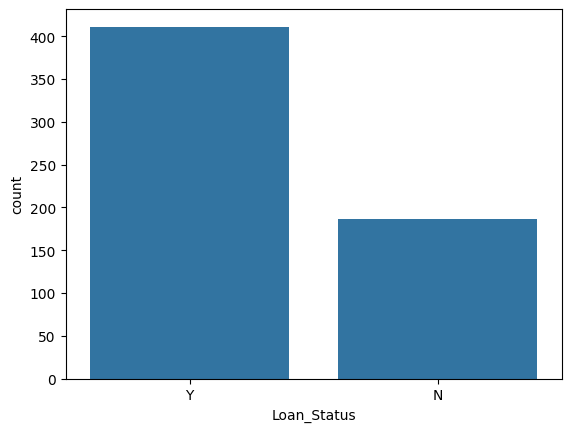

In [30]:
sns.countplot(x='Loan_Status',data=loan)
plt.show()

Insights: How many customers got loans?

Gender

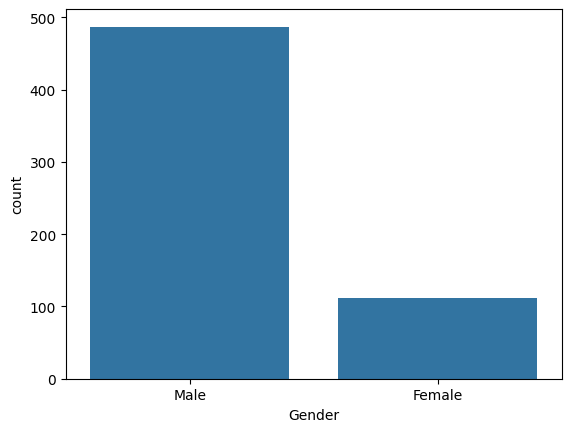

In [31]:
sns.countplot(x='Gender',data=loan)
plt.show()

Education

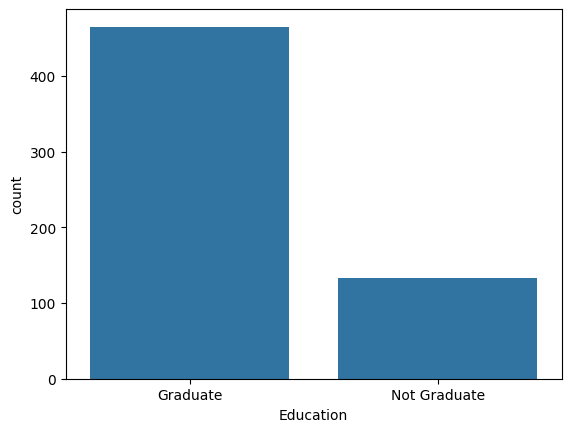

In [32]:
sns.countplot(x='Education',data=loan)
plt.show()

Property Area

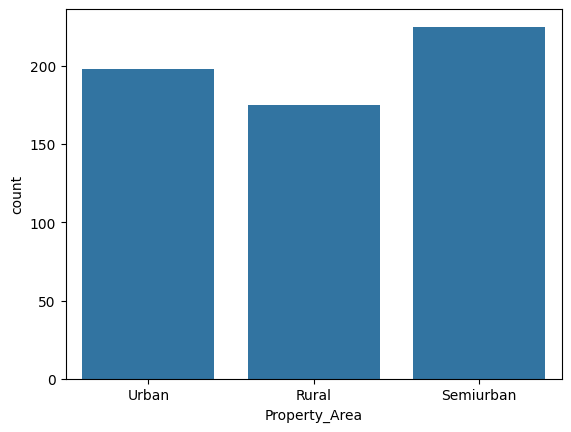

In [33]:
sns.countplot(x='Property_Area',data=loan)
plt.show()

Applicant Income Distribution

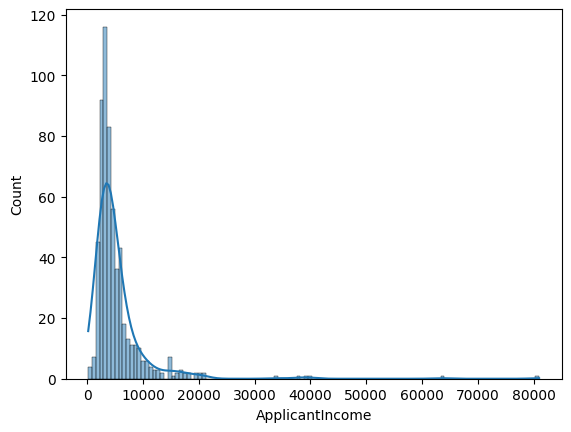

In [34]:
sns.histplot(loan['ApplicantIncome'],kde=True)
plt.show()

Loan Amount Distribution

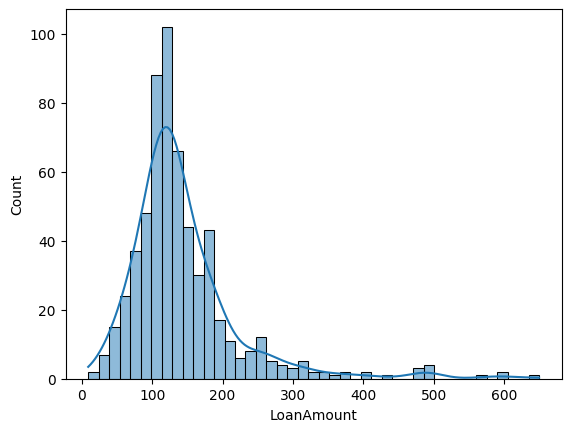

In [35]:
sns.histplot(loan['LoanAmount'],kde=True)
plt.show()

BOXPLOT

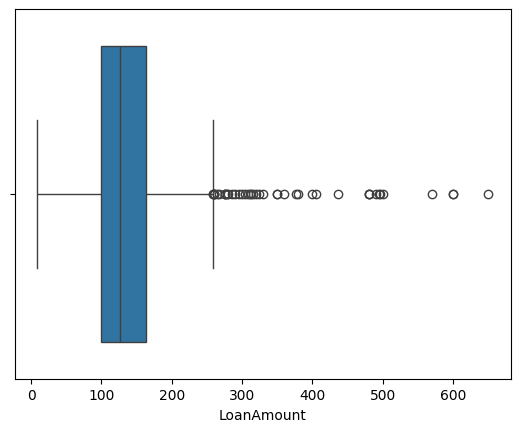

In [36]:
sns.boxplot(x=loan['LoanAmount'])
plt.show()

**Notes**

EDA helps us understand

Patterns

Trends

Outliers

Relationships before building the model.

**Step 6 Feature Engineering**

Create Total Income

In [37]:
loan['TotalIncome'] = loan['ApplicantIncome'] + loan['CoapplicantIncome']

In [38]:
loan

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0


Log Transform

In [39]:
loan['LoanAmount_Log'] = np.log(loan['LoanAmount'])

In [40]:
loan

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmount_Log
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,5849.0,4.844187
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,4.852030
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,4.189655
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,4.787492
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0,4.262680
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0,3.688879
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0,5.533389
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0,5.231109


Drop unnecessary column

In [41]:
loan.drop('Loan_ID', axis=1, inplace=True)

In [42]:
loan

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmount_Log
0,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,5849.0,4.844187
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,4.852030
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,4.189655
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,4.787492
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0,4.262680
594,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0,3.688879
595,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0,5.533389
596,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0,5.231109


**Notes**

Feature Engineering means creating better features from existing data.

Better features improve prediction accuracy.

**Step 7 Encoding**

In [43]:
loan.select_dtypes(include='object')

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,Graduate,No,Urban,Y
1,Male,Yes,Graduate,No,Rural,N
2,Male,Yes,Graduate,Yes,Urban,Y
3,Male,Yes,Not Graduate,No,Urban,Y
4,Male,No,Graduate,No,Urban,Y
...,...,...,...,...,...,...
593,Female,No,Graduate,No,Rural,Y
594,Male,Yes,Graduate,No,Rural,Y
595,Male,Yes,Graduate,No,Urban,Y
596,Male,Yes,Graduate,No,Urban,Y


In [44]:
le = LabelEncoder()

for col in loan.select_dtypes(include='object'):
    loan[col] = le.fit_transform(loan[col])

In [45]:
loan

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmount_Log
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1,5849.0,4.844187
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,4.852030
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,4.189655
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,4.787492
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,1,2900.0,4.262680
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,1,4106.0,3.688879
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,1,8312.0,5.533389
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,1,7583.0,5.231109


**Notes**

Machine Learning algorithms cannot understand text.

Encoding converts text into numbers.

**Step 8 Define X and y**

In [46]:
X = loan.drop(['Loan_Status'], axis=1)

y = loan['Loan_Status']

In [47]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanAmount_Log
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,5849.0,4.844187
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,6091.0,4.852030
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,3000.0,4.189655
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,4941.0,4.787492
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,6000.0,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,2900.0,4.262680
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,4106.0,3.688879
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,8312.0,5.533389
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,7583.0,5.231109


In [48]:
loan['ApplicantIncome'].mean()

np.float64(5292.252508361204)

In [49]:
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
593,1
594,1
595,1
596,1


**Step 9 Train-Test Split**

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
print(X_train)
print(y_train)

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
145       0        0         0.0          0              0            10000   
9         1        1         1.0          0              0            12841   
374       0        0         0.0          0              0             6000   
521       0        0         0.0          1              1            18165   
188       1        0         0.0          0              0             3858   
..      ...      ...         ...        ...            ...              ...   
71        1        0         0.0          0              0             3500   
106       1        1         2.0          0              0             3800   
270       1        1         0.0          0              0             3993   
435       1        1         0.0          0              0             7333   
102       1        1         0.0          0              0             4652   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

In [52]:
y_train

,Loan_Status
145,0
9,0
374,1
521,1
188,1
...,...
71,1
106,0
270,1
435,1


In [53]:
y_test

,Loan_Status
110,0
287,0
563,1
77,0
181,1
...,...
398,1
433,1
148,1
493,1


**Notes**

80% → Training

20% → Testing

**Step 10 Feature Scaling (Very Important)**

**What is Feature Scaling?**

Feature Scaling is the process of bringing numerical features to a similar scale without changing their underlying relationships. It ensures that no feature dominates the model simply because it has larger numerical values.

**Why is Feature Scaling Required?**

In this dataset, different features have very different ranges.

| Feature         | Example Values |
| --------------- | -------------- |
| ApplicantIncome | 1500 – 50000   |
| LoanAmount      | 50 – 700       |
| Credit_History  | 0 or 1         |

Since income values are much larger than loan amount or credit history values, the model may assign more importance to income simply because of its larger scale.

Feature scaling ensures that all numerical features contribute fairly during model training.

**Why is Feature Scaling Important for Logistic Regression?**

Logistic Regression uses gradient-based optimization to find the best model parameters. If features have very different scales, the optimization process may converge slowly or produce less accurate results.

**Scaling helps by:**
Bringing all numerical features to a comparable scale.

Speeding up the training process.

Improving model stability and performance.


**StandardScaler**

In this project, we use StandardScaler, which transforms the data so that:

Mean = 0

Standard Deviation = 1

The transformation formula is:

Z=(X−μ​)/σ
	​

Where:

X = Original value

μ = Mean of the feature

σ = Standard deviation of the feature

In [54]:
scaler=StandardScaler()

X_train[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','TotalIncome','LoanAmount_Log']] = scaler.fit_transform(X_train[['ApplicantIncome',
                      'CoapplicantIncome',
                      'LoanAmount',
                      'Loan_Amount_Term',
                      'TotalIncome',
                      'LoanAmount_Log']])

X_test[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','TotalIncome','LoanAmount_Log']] = scaler.transform(X_test[['ApplicantIncome',
                    'CoapplicantIncome',
                    'LoanAmount',
                    'Loan_Amount_Term',
                    'TotalIncome',
                    'LoanAmount_Log']])

**Notes**

Logistic Regression performs better when numerical features are on a similar scale.

In [55]:
X_train

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanAmount_Log
145,0,0,0.0,0,0,0.788685,0.025458,0.919830,0.297638,1.0,0,0.756286,1.124971
9,1,1,1.0,0,0,1.268955,3.304056,2.363002,0.297638,1.0,1,2.694716,2.004009
374,0,0,0.0,0,0,0.112487,-0.561743,0.116774,0.297638,1.0,2,-0.148198,0.391568
521,0,0,0.0,1,1,2.168976,-0.561743,-0.244019,0.297638,1.0,2,1.793745,-0.052069
188,1,0,0.0,0,0,-0.249618,-0.561743,-0.814304,0.297638,1.0,1,-0.490133,-1.048471
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,0,0.0,0,0,-0.310138,-0.561743,-0.756112,-0.610860,1.0,1,-0.547282,-0.920881
106,1,1,2.0,0,0,-0.259423,0.707119,0.815083,0.297638,0.0,2,0.075289,1.043225
270,1,1,0.0,0,0,-0.226796,0.592217,0.710337,0.297638,1.0,1,0.054058,0.958000
435,1,1,0.0,0,0,0.337830,2.375320,0.337906,-0.610860,1.0,0,1.394820,0.621715


**IMPORTANT NOTE-**


**Why do we use fit_transform() for the training data?**

The scaler first learns the mean and standard deviation from the training data using fit(), and then transforms the training data using those statistics.

**Why do we use only transform() for the test data?**

The test data should be transformed using the same mean and standard deviation learned from the training data. This prevents data leakage and ensures a fair evaluation of the model.

In [56]:
loan

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmount_Log
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1,5849.0,4.844187
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,4.852030
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,4.189655
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,4.787492
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,1,2900.0,4.262680
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,1,4106.0,3.688879
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,1,8312.0,5.533389
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,1,7583.0,5.231109


In [57]:
X_train.drop('LoanAmount',axis=1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanAmount_Log
145,0,0,0.0,0,0,0.788685,0.025458,0.297638,1.0,0,0.756286,1.124971
9,1,1,1.0,0,0,1.268955,3.304056,0.297638,1.0,1,2.694716,2.004009
374,0,0,0.0,0,0,0.112487,-0.561743,0.297638,1.0,2,-0.148198,0.391568
521,0,0,0.0,1,1,2.168976,-0.561743,0.297638,1.0,2,1.793745,-0.052069
188,1,0,0.0,0,0,-0.249618,-0.561743,0.297638,1.0,1,-0.490133,-1.048471
...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,0,0.0,0,0,-0.310138,-0.561743,-0.610860,1.0,1,-0.547282,-0.920881
106,1,1,2.0,0,0,-0.259423,0.707119,0.297638,0.0,2,0.075289,1.043225
270,1,1,0.0,0,0,-0.226796,0.592217,0.297638,1.0,1,0.054058,0.958000
435,1,1,0.0,0,0,0.337830,2.375320,-0.610860,1.0,0,1.394820,0.621715


In [58]:
X_test.drop('LoanAmount',axis=1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanAmount_Log
110,1,1,0.0,1,0,-0.297966,0.888284,0.297638,0.0,0,0.120944,0.339553
287,0,0,0.0,0,0,0.013931,-0.561743,2.114633,0.0,2,-0.241264,0.217328
563,1,0,0.0,0,0,-0.355950,0.403650,0.297638,1.0,2,-0.153306,-0.308055
77,1,1,3.0,0,0,-0.366431,0.848104,-0.610860,0.0,1,0.038094,0.678127
181,1,1,0.0,0,1,5.715975,1.112450,0.297638,1.0,1,5.901436,-0.133815
...,...,...,...,...,...,...,...,...,...,...,...,...
398,1,1,0.0,1,0,-0.535481,0.284165,0.297638,1.0,2,-0.376953,-0.219040
433,1,0,3.0,1,0,-0.106095,0.140713,0.297638,1.0,1,-0.036455,0.286150
148,1,1,0.0,0,1,-0.466170,0.759988,0.297638,1.0,0,-0.095998,0.339553
493,1,1,2.0,0,0,-0.308447,0.994728,0.297638,1.0,0,0.159256,1.279085


**Why drop the original LoanAmount?**

If we keep both columns:

LoanAmount

LoanAmount_Log

they contain almost the same information. The second is simply a transformed version of the first.

This can cause:

Redundant information

Multicollinearity (high correlation between predictors)

Unstable coefficients in Logistic Regression

Harder interpretation of the model

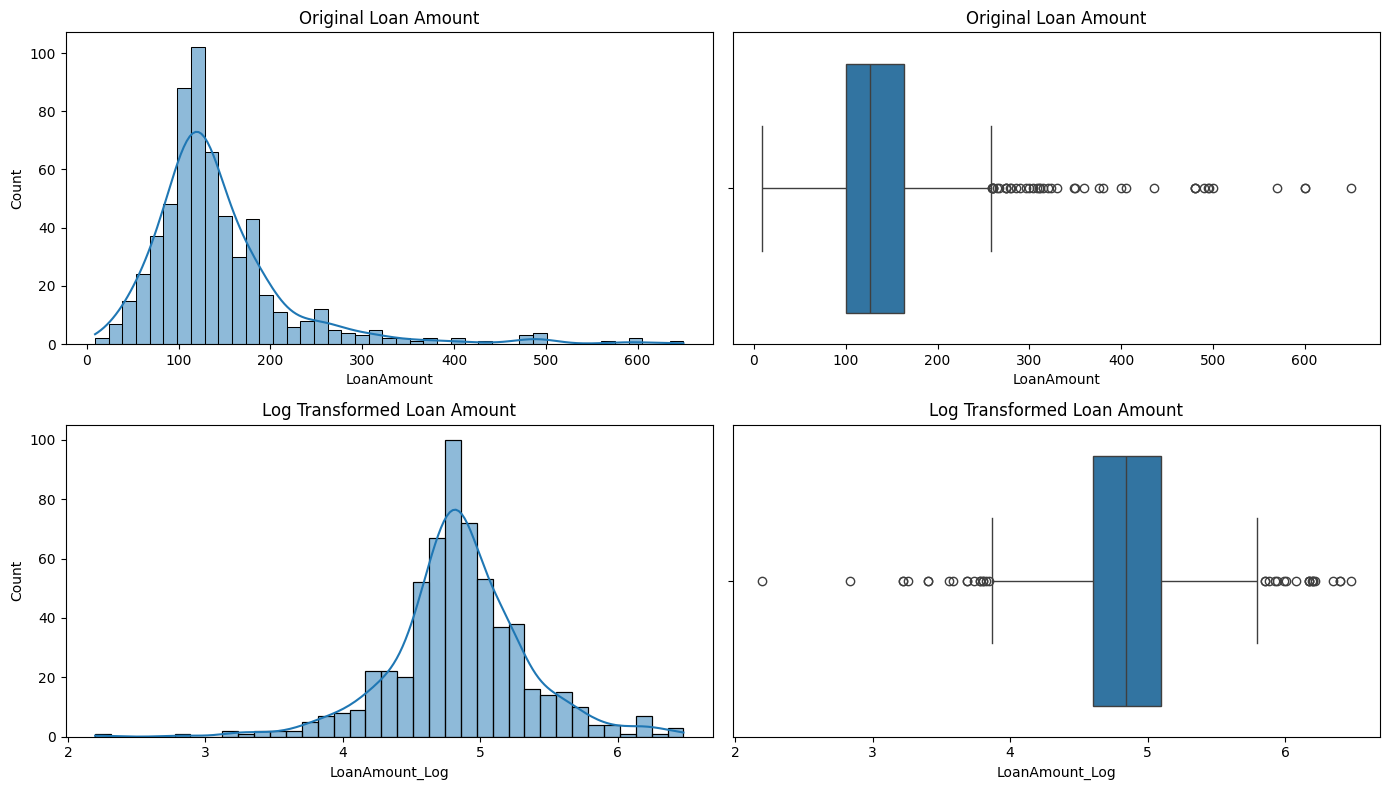

In [59]:
plt.figure(figsize=(14,8))

# Original Histogram
plt.subplot(2,2,1)
sns.histplot(loan['LoanAmount'], kde=True)
plt.title("Original Loan Amount")

# Original Boxplot
plt.subplot(2,2,2)
sns.boxplot(x=loan['LoanAmount'])
plt.title("Original Loan Amount")

# Log Histogram
plt.subplot(2,2,3)
sns.histplot(loan['LoanAmount_Log'], kde=True)
plt.title("Log Transformed Loan Amount")

# Log Boxplot
plt.subplot(2,2,4)
sns.boxplot(x=loan['LoanAmount_Log'])
plt.title("Log Transformed Loan Amount")

plt.tight_layout()
plt.show()

**Before Log Transformation:**

Distribution is right-skewed (positively skewed).

A few very large loan amounts stretch the distribution.

Outliers are more prominent.

**After Log Transformation:**

Distribution becomes more symmetric and closer to a normal distribution.

Extreme values are compressed.

The influence of outliers is reduced.

This often improves the performance of models like Logistic Regression

**Step 11 Model Building**

In [60]:
lr=LogisticRegression(random_state=42)

lr.fit(X_train,y_train)

LogisticRegression(random_state=42)

**Notes**

The model learns the relationship between the input features and the target variable to estimate the probability of loan approval.

**Step 12 Prediction**

In [61]:
y_pred=lr.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [62]:
y_test

,Loan_Status
110,0
287,0
563,1
77,0
181,1
...,...
398,1
433,1
148,1
493,1


**Step 13 Model Evaluation**

Accuracy

In [63]:
accuracy_score(y_test,y_pred)

0.8166666666666667

Confusion Matrix

In [64]:
confusion_matrix(y_test,y_pred)

array([[14, 21],
       [ 1, 84]])

Classification Report

In [65]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.40      0.56        35
           1       0.80      0.99      0.88        85

    accuracy                           0.82       120
   macro avg       0.87      0.69      0.72       120
weighted avg       0.84      0.82      0.79       120



The Classification Report is a complete performance report card of the model. It shows how well the model predicts each class separately (Loan Approved and Loan Rejected) using Precision, Recall, F1-Score, and Support, along with the overall Accuracy.

Precision

In [66]:
precision_score(y_test,y_pred)

0.8

Recall

In [67]:
recall_score(y_test,y_pred)

0.9882352941176471

F1-Score

In [68]:
f1_score(y_test,y_pred)

0.8842105263157894

| Question                                                        | Metric    |
| --------------------------------------------------------------- | --------- |
| Out of all decisions, how many were correct?                    | Accuracy  |
| When the model approved a loan, how often was it correct?       | Precision |
| Out of all deserving customers, how many did the model approve? | Recall    |
| Is there a good balance between Precision and Recall?           | F1 Score  |
| How many actual customers belong to each class?                 | Support   |


| Situation                                                              | Most Important Metric | Business Reason                                                       |
| ---------------------------------------------------------------------- | --------------------- | --------------------------------------------------------------------- |
| Avoid giving loans to defaulters                                       | Precision             | Every wrong approval can result in financial loss and increased NPAs. |
| Capture as many eligible customers as possible                         | Recall                | Missing good customers means losing revenue and customer trust.       |
| Overall model performance                                              | Accuracy              | Useful when approved and rejected cases are fairly balanced.          |
| Need a balance between avoiding bad loans and approving good customers | F1 Score              | Combines Precision and Recall into one balanced measure.              |


**Accuracy:** Overall, how often is my model correct?

**Precision:** When my model says "Yes" (Approve), can I trust it?

**Recall:** Out of all the people who should have received a "Yes", how many did my model actually find?

**Step 14 Coefficient Interpretation (Unique to Logistic Regression)**

In [69]:
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
9,Credit_History,3.228632
1,Married,0.412870
10,Property_Area,0.230011
7,LoanAmount,0.110242
2,Dependents,0.018056
4,Self_Employed,-0.021110
5,ApplicantIncome,-0.043021
11,TotalIncome,-0.078130
0,Gender,-0.081918
6,CoapplicantIncome,-0.082809


**Notes**

Positive coefficient → Increases the probability of loan approval.

Negative coefficient → Decreases the probability of loan approval.

Larger absolute values indicate a stronger influence on the prediction.

**What does positive coefficient mean?**

Positive means

Increasing this feature increases the probability of Loan Approval.

Example

Income

₹20,000

↓

₹50,000

Approval probability increases !

**What does negative coefficient mean?**

Negative means

Increasing this feature decreases the probability of Loan Approval.

Example

Loan Amount

₹1 lakh

↓

₹10 lakh

Approval probability decreases !

**Step 15 Predict New Customer**

In [70]:
lr.predict(X_test.iloc[[0]])

array([0])

In [71]:
lr.predict_proba(X_test.iloc[[0]])

array([[0.93006922, 0.06993078]])

In [72]:
sample = X_test.iloc[[6]]

prediction = lr.predict(sample)[0]
probability = lr.predict_proba(sample)

print("Probability of Rejection :", round(probability[0][0] * 100, 2), "%")
print("Probability of Approval  :", round(probability[0][1] * 100, 2), "%")

if prediction == 1:
    print("Final Prediction : Loan Approved")
else:
    print("Final Prediction : Loan Rejected")

Probability of Rejection : 11.29 %
Probability of Approval  : 88.71 %
Final Prediction : Loan Approved


**Notes**

predict() returns the predicted class (Approved or Rejected).

predict_proba() returns the probability of each class, helping explain the model's confidence.

***PHASE 2 : MAKING OUR MACHINE LEARNING MODEL GENAI ENABLED***

**NOTE:**

So far, we have successfully built a Machine Learning model that predicts whether a loan application will be Approved or Rejected.

However, traditional Machine Learning has one major limitation—it only provides predictions and probabilities. It cannot explain its decisions, answer customer queries, generate reports, or provide personalized financial guidance.

To overcome these limitations, we will now integrate Generative AI into our existing Loan Prediction System.

By adding a Large Language Model (LLM), our application will be able to:

✔ Explain loan predictions in simple language.

✔ Suggest improvements for rejected applications.

✔ Provide personalized financial advice.


This integration transforms our Machine Learning project into an AI-powered intelligent banking assistant.

**STEP 1 : Installing Required Libraries**

In [73]:
!pip install -U google-genai

In [74]:
# Import Gemini SDK

from google import genai

**WHY ARE WE INSTALLING THIS LIBRARY?**

Till now, our project was only a Machine Learning project.
The ML model can predict whether the loan will be approved or rejected,
but it cannot explain the prediction in human language.

Google Generative AI (Gemini) allows us to connect our project with a
Large Language Model (LLM).

Using this library, our project can:

• Explain predictions

• Generate reports

• Answer customer questions

• Give financial suggestions

• Generate emails

In simple words,

Machine Learning predicts and Generative AI explains !

This converts our ML project into an AI-powered application.

**STEP 2 : Configuring Gemini API**

In [75]:
!pip freeze | grep -E "google-genai|google-generativeai"

google-genai==2.11.0


In [76]:
import sys; print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [77]:
from google import genai

client = genai.Client(api_key="YOUR API KEY")

print("Client Created Successfully")

Client Created Successfully


**NOTE:** genai.Client() creates a secure connection between our notebook and Google Gemini servers.


IMPORTANT : GEMINI API KEY SETUP (READ BEFORE PROCEEDING)
==========================================================

To use the Generative AI features in this project, every student must create
their own FREE Gemini API Key.

Google provides a free API key through Google AI Studio.

Follow the steps below carefully.

**Step 1 : Visit Google AI Studio**

Open the following website:

👉 https://aistudio.google.com/app/apikey

**Step 2 : Sign in**

Sign in using your Google (Gmail) account.
If you don't have a Gmail account, create one first.

**Step 3 : Create API Key**

Click on Create API Key

Google will automatically generate your unique API Key.

Example:

AQ.xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

**Step 4 : Copy Your API Key**

Copy the generated API Key and keep it secure.

⚠️ Never share your API Key publicly because anyone can use it to access your API quota.

In [80]:
from google import genai

client = genai.Client(api_key="YOUR API KEY")

for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-omni-flash-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
mod

Out of many models,we chose gemini-3.5-flash as its the latest version replacing old version of gemini-2.5-flash

**STEP 3 : Test Gemini**

In [81]:
from google import genai

client = genai.Client(api_key="YOUR API KEY")

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="Say hello in one sentence."
)

print(response.text)

Hello, it is a pleasure to meet you, and I hope you are having a wonderful day!


Before integrating AI into our project,
we first verify whether the connection
with Gemini has been established successfully.

This helps us identify API issues early.

generate_content() sends our prompt to Google's AI model.

Gemini processes the prompt and returns the generated response.

response.text contains the AI-generated answer.

Gemini runs on Google's cloud servers.

Our notebook cannot directly access those servers.

The API Key acts like a secure password
that authenticates our application.

Without an API key,
Google will not allow us to use the AI model.

**BUSINESS LOGIC**

Think of an ATM card.

You insert the card.

Then enter the PIN.

Only then can you withdraw money.

Similarly,

API Key = PIN

Gemini = ATM

**STEP 4 : Convert Customer Data into Dictionary**

In [83]:
sample = X_test.iloc[[6]]

Machine Learning models understand DataFrames.

Large Language Models understand natural language.

Therefore,
we convert the DataFrame into a dictionary
before sending it to Gemini.

In [84]:
customer_details = sample.to_dict(orient="records")[0]

customer_details

{'Gender': 1,
 'Married': 1,
 'Dependents': 2.0,
 'Education': 0,
 'Self_Employed': 0,
 'ApplicantIncome': -0.3608523970043496,
 'CoapplicantIncome': -0.31501949141211405,
 'LoanAmount': -0.8841351780879506,
 'Loan_Amount_Term': 0.2976375512761145,
 'Credit_History': 1.0,
 'Property_Area': 2,
 'TotalIncome': -0.4834285788643727,
 'LoanAmount_Log': -1.2131528349487106}

to_dict() converts every column into

Feature : Value, which becomes easy for Gemini to read.

**STEP 5 : Convert Prediction into Human Language**

In [85]:
loan_status = "Approved" if prediction==1 else "Rejected"

Machine Learning returns 0 or 1

Humans don't understand these values.

Therefore,

we convert

0 → Rejected

1 → Approved

before sending the result to Gemini.

**STEP 6 : Calculate Confidence**

In [86]:
probability = lr.predict_proba(sample)

approval_probability = round(probability[0][1]*100,2)

rejection_probability = round(probability[0][0]*100,2)

The model not only predicts Approved or Rejected

It also tells us how confident it is !

Confidence makes predictions more trustworthy !

**STEP 7 : AI Loan Explanation**

In [87]:
prompt = f"""
You are an experienced Loan Officer.

Customer Details:
{customer_details}

Prediction:
{loan_status}

Approval Probability:
{approval_probability}%

Explain:
1. Why this prediction happened.
2. Mention important features.
3. Keep the explanation simple (100 words).

"""

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=prompt
)

print(response.text)

As your loan officer, I am pleased to approve your application with a strong 88.71% confidence. 

The main driver behind this decision is your perfect **Credit History (1.0)**, demonstrating outstanding financial responsibility. Additionally, while your **Total Income** is below average, your requested **Loan Amount** is exceptionally low (well below average). This keeps your debt-to-income ratio highly favorable and affordable. Your stable profile as a married applicant further reduces risk. 

In short, your excellent credit record and modest loan request made this an easy approval!


**IMPORTANT NOTE**

Here we combine

Machine Learning plus Generative AI

The ML model predicts the outcome.

Gemini converts that prediction into
a human-friendly explanation.

**STEP 8 : AI Financial Advisor**

In [88]:
prompt = f"""
You are a Financial Advisor.

Customer Details:
{customer_details}

Loan Status:
{loan_status}

Give financial advice in less than 100 words.
"""

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=prompt
)

print(response.text)

Congratulations on your loan approval! Your excellent credit history was key to this success. 

Since you are supporting a family of four on a modest income, careful budgeting is crucial. Fortunately, your approved loan amount is relatively small and manageable. 

**My Advice:**
1. **Automate Payments:** Set up automatic repayments to protect your strong credit score.
2. **Limit New Debt:** Avoid taking on any additional credit cards or loans.
3. **Build a Buffer:** Focus on building a modest emergency fund for family expenses. 

Consistent, timely payments will secure your long-term financial health.


**IMPORTANT NOTE**

Notice something interesting. We are using the SAME Gemini model.

Only the prompt changes.

This is the power of Prompt Engineering.

One LLM

Many applications.

**Conclusion**


In this project, we successfully developed a Machine Learning-based Loan Prediction System capable of predicting whether a customer's loan application is likely to be Approved or Rejected.

The project began with data preprocessing, where missing values, categorical variables, and feature transformations were handled to prepare a clean dataset. We then performed Exploratory Data Analysis (EDA) to understand customer behavior and identify important factors affecting loan approval.

Next, we built and evaluated multiple Machine Learning models to identify the most suitable algorithm for loan prediction. After selecting the best-performing model, we used it to make predictions for new customer loan applications and calculated the prediction probabilities to measure the model's confidence.

However, traditional Machine Learning models have one major limitation—they only provide predictions without explaining the reasoning behind them. A customer receiving a loan decision naturally wants to know why the application was approved or rejected and what factors influenced the decision.

To overcome this limitation, we integrated Google's Gemini Large Language Model (LLM) into our project using the latest Gemini 3.5 Flash API. This marked the beginning of the Generative AI layer in our Loan Prediction System.

Using Generative AI, the application now converts numerical predictions into simple, human-readable explanations. Instead of displaying only "Approved" or "Rejected," the system can explain the prediction in natural language by considering the customer's profile and the model's confidence score.

This integration demonstrates how Machine Learning and Generative AI complement each other:

• Machine Learning performs data-driven prediction.

• Generative AI interprets and explains those predictions in a way that customers and business users can easily understand.

At this stage, our project has evolved from a traditional predictive model into an intelligent AI-powered loan decision support system capable of delivering both accurate predictions and meaningful explanations.